# Periodic Fourier–AR(1) Spatio-Temporal Gaussian Process
## Stats 669 Research — Python Implementation

**Author:** Pranav Tikkawar | **Date:** May 2026

This notebook is a direct Python translation of `sim_crosscorr_fft.r`.  
It simulates a Gaussian spatio-temporal process on $[0, 2\pi]$ using:
- A truncated real Fourier series representation
- Block-diagonal AR(1) temporal dynamics with phase rotation $\theta_j$ and correlated innovations $\phi_j$
- Both **direct summation** $O(NJ)$ and **Inverse FFT** $O(N \log N)$ field evaluation

---
### Notebook Structure
| Section | Content |
|---------|---------|
| 1 | Imports & dependencies |
| 2 | Helper functions (spectrum, persistence, matrices) |
| 3 | Main simulation function |
| 4 | Spatial field evaluation — Direct & FFT |
| 5 | Post-processing helpers (amplitude, phase, diagnostics) |
| 6 | Run simulation & validate |
| 7 | Diagnostic plots |


---
## Section 1: Imports & Dependencies

Standard scientific Python stack only — no exotic dependencies required.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import warnings

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
print("Imports OK.")


Imports OK.


---
## Section 2: Helper Functions

### 2a. Matérn-like Fourier Spectrum

$$\tilde{\sigma}_j^2 = (\kappa^2 + j^2)^{-(\nu + 1/2)}, \quad \kappa = \frac{\sqrt{2\nu}}{\ell}$$

Normalized so $\sum_j \sigma_j^2 = \sigma^2_{\text{tot}}$.
Larger $\nu$ → smoother fields. Larger $\ell$ → longer spatial range.


In [2]:
def matern_spectrum(J, nu, ell, total_var=1.0):
    """
    Compute Matérn-like mode variances sigma_j^2 for j = 0,...,J.
    Returns array of shape (J+1,).
    """
    kappa    = np.sqrt(2 * nu) / ell
    j        = np.arange(J + 1)
    raw_spec = (kappa**2 + j**2) ** (-(nu + 0.5))
    return total_var * raw_spec / raw_spec.sum()


### 2b. Power-Law Temporal Persistence

$$\rho_j = \frac{1}{(1 + \lambda j^\alpha)^\beta}, \quad j \geq 1 \qquad \rho_0 \text{ set manually}$$

Power-law (vs. exponential) gives longer memory to fine-scale features — realistic for physical systems.


In [3]:
def rho_function(J, lam, alpha, beta, rho0=0.95):
    """
    Compute mode-specific AR(1) persistence rho_j for j = 0,...,J.

    Parameters: lam=lambda (decay strength), alpha (freq exponent), beta (power-law exponent).
    Returns array of shape (J+1,).
    """
    j   = np.arange(J + 1, dtype=float)
    rho = 1.0 / (1.0 + lam * j**alpha)**beta
    rho[0] = rho0   # j=0: algebraic formula gives rho=1 (nonstationary), override manually
    return np.maximum(rho, 0.0)


### 2c. Rotation Angles and Innovation Correlations

Default parameterizations:
$$\theta_j = \frac{\theta_0}{j}, \quad \phi_j = \frac{\phi_0}{1+j}, \quad j = 1,\ldots,J$$

Setting $\theta_0 = 0$ or $\phi_0 = 0$ recovers simpler (independent/non-rotating) models.


In [4]:
def build_theta_vec(J, theta0=0.3):
    """theta_j = theta0 / j for j=1,...,J. Returns (J,) array."""
    return theta0 / np.arange(1, J + 1, dtype=float)

def build_phi_vec(J, phi0=0.5):
    """phi_j = phi0 / (1+j) for j=1,...,J. Requires |phi_j| < 1. Returns (J,) array."""
    phi = phi0 / (1.0 + np.arange(1, J + 1, dtype=float))
    if np.any(np.abs(phi) >= 1.0):
        raise ValueError("phi_j must satisfy |phi_j| < 1 for all j")
    return phi


### 2d. Transition Matrix $M_j$

$$M_j = \rho_j \begin{pmatrix} \cos\theta_j & -\sin\theta_j \\ \sin\theta_j & \cos\theta_j \end{pmatrix}$$

Eigenvalues $\rho_j e^{\pm i\theta_j}$: modulus $= \rho_j < 1$ guarantees stationarity for any $\theta_j$.  
When $\theta_j = 0$: reduces to $\rho_j I_2$ (cosine and sine evolve independently).


In [5]:
def build_Mj(rho_j, theta_j):
    """Build 2x2 rotation-scaling transition matrix for mode j."""
    c = np.cos(theta_j);  s = np.sin(theta_j)
    return rho_j * np.array([[c, -s], [s, c]])


### 2e. Innovation Covariance $\Sigma_{\varepsilon,j}$

From the Lyapunov equation $\Sigma_j = M_j \Sigma_j M_j^\top + \Sigma_{\varepsilon,j}$ with $M_j M_j^\top = \rho_j^2 I_2$:

$$\Sigma_{\varepsilon,j} = \sigma_j^2(1-\rho_j^2) \begin{pmatrix} 1 & \phi_j \\ \phi_j & 1 \end{pmatrix}$$

**Key fact:** this is independent of $\theta_j$ — rotation affects dynamics, not the stationary covariance.


In [6]:
def build_Sigma_eps_j(sigma2_j, rho_j, phi_j):
    """2x2 innovation covariance (derived from Lyapunov equation). Requires |phi_j| < 1."""
    scale = sigma2_j * (1.0 - rho_j**2)
    return scale * np.array([[1.0, phi_j], [phi_j, 1.0]])

def build_Sigma_init_j(sigma2_j, phi_j):
    """2x2 stationary initial covariance: sigma2_j * [[1, phi_j],[phi_j, 1]]."""
    return sigma2_j * np.array([[1.0, phi_j], [phi_j, 1.0]])


---
## Section 3: Main Simulation Function

`simulate_fourier_ar1()` advances the Fourier coefficients forward in time.

**AR(1) update for mode $j \geq 1$:**
$$\begin{pmatrix} a_j(t+1) \\ b_j(t+1) \end{pmatrix} = M_j \begin{pmatrix} a_j(t) \\ b_j(t) \end{pmatrix} + \boldsymbol{\eta}_{j,t}, \quad \boldsymbol{\eta}_{j,t} \sim \mathcal{N}_2(\mathbf{0},\, \Sigma_{\varepsilon,j})$$

**Python vs R indexing note:**  
R uses 1-based indexing: `a[t, j+1]`. Python uses 0-based: `a[t, j]`.  
`b[:, 0]` is never used (no $\sin(0 \cdot x)$ term).


In [7]:
def simulate_fourier_ar1(T, J, nu, ell, lam, alpha, beta,
                         total_var=1.0, rho0=0.95,
                         theta_vec=None, phi_vec=None, seed=None):
    """
    Simulate Fourier coefficient arrays a[t,j] and b[t,j] for the
    Periodic Fourier-AR(1) spatio-temporal model.

    Parameters
    ----------
    T, J      : time steps, Fourier truncation level
    nu, ell   : Matérn smoothness and range
    lam       : temporal decay strength (lambda)
    alpha, beta : power-law persistence parameters
    total_var : total marginal variance of X_t(x)
    rho0      : persistence for j=0 constant mode
    theta_vec : (J,) rotation angles; default build_theta_vec(J, 0.3)
    phi_vec   : (J,) innovation correlations; default build_phi_vec(J, 0.5)
    seed      : RNG seed for reproducibility

    Returns
    -------
    dict: a (T,J+1), b (T,J+1), sigma2 (J+1,), rho (J+1,),
          theta_vec (J,), phi_vec (J,), params dict
    """
    rng = np.random.default_rng(seed)

    if theta_vec is None: theta_vec = build_theta_vec(J, theta0=0.3)
    if phi_vec   is None: phi_vec   = build_phi_vec(J, phi0=0.5)

    assert len(theta_vec) == J and len(phi_vec) == J
    assert np.all(np.abs(phi_vec) < 1.0), "All |phi_j| must be < 1"
    assert 0 < rho0 < 1

    sigma2 = matern_spectrum(J, nu, ell, total_var)
    rho    = rho_function(J, lam, alpha, beta, rho0)

    # Storage: a[t,j] = cosine coeff for mode j at time t (0-indexed)
    a = np.zeros((T, J + 1))
    b = np.zeros((T, J + 1))

    # ── Initialize t=0 from stationary distribution ──────────────────────────
    a[0, 0] = rng.normal(0.0, np.sqrt(sigma2[0]))
    for j in range(1, J + 1):
        draw   = rng.multivariate_normal([0., 0.], build_Sigma_init_j(sigma2[j], phi_vec[j-1]))
        a[0, j] = draw[0];  b[0, j] = draw[1]

    # ── Forward simulation t = 1,...,T-1 ─────────────────────────────────────
    for t in range(1, T):
        # j=0: scalar AR(1)
        a[t, 0] = rho[0] * a[t-1, 0] + rng.normal(0., np.sqrt(sigma2[0] * (1 - rho[0]**2)))

        # j=1,...,J: 2x2 AR(1) with rotation and correlated innovations
        for j in range(1, J + 1):
            Mj        = build_Mj(rho[j], theta_vec[j-1])
            Sigma_eps = build_Sigma_eps_j(sigma2[j], rho[j], phi_vec[j-1])
            eta       = rng.multivariate_normal([0., 0.], Sigma_eps)
            state_new = Mj @ np.array([a[t-1, j], b[t-1, j]]) + eta
            a[t, j]   = state_new[0];  b[t, j] = state_new[1]

    return dict(a=a, b=b, sigma2=sigma2, rho=rho,
                theta_vec=theta_vec, phi_vec=phi_vec,
                params=dict(T=T, J=J, nu=nu, ell=ell, lam=lam,
                            alpha=alpha, beta=beta, total_var=total_var, rho0=rho0))


---
## Section 4: Spatial Field Evaluation

### 4a. Direct Summation — $O(NJ)$

Evaluates $X_t(x) = a_0(t) + \sum_{j=1}^J [a_j(t)\cos(jx) + b_j(t)\sin(jx)]$  
at any grid (regular or irregular).  
**Use when:** grid is irregular, $N$ is small, or as a reference implementation.


In [8]:
def reconstruct_field_direct(a, b, x_grid):
    """
    Direct Fourier summation: X[t,n] = X_t(x_grid[n]).
    Cost: O(T * N * J).

    Parameters: a (T,J+1), b (T,J+1), x_grid (N,)
    Returns:    X (T, N)
    """
    J = a.shape[1] - 1
    X = np.outer(a[:, 0], np.ones(len(x_grid)))  # j=0 constant mode
    for j in range(1, J + 1):
        X += np.outer(a[:, j], np.cos(j * x_grid))
        X += np.outer(b[:, j], np.sin(j * x_grid))
    return X


### 4b. Inverse FFT on a Dense Regular Grid — $O(N_{\text{fft}} \log N_{\text{fft}})$

Evaluates on the equally-spaced grid $x_k = 2\pi k / N_{\text{fft}}$ using NumPy's `ifft`.

**Coefficient packing** (real Fourier → complex DFT):

$$\tilde{c}_k = \begin{cases} a_0 & k=0 \\ (a_k - ib_k)/2 & k=1,\ldots,J \\ (a_{N-k}+ib_{N-k})/2 & k=N-J,\ldots,N-1 \\ 0 & \text{otherwise} \end{cases}$$

Then $X_t(x_k) = N_{\text{fft}} \cdot \text{IFFT}(\tilde{c})[k]$.

**Nyquist constraint:** $N_{\text{fft}} > 2J$. Recommend $N_{\text{fft}} \geq 4J$, power of 2.


In [9]:
def reconstruct_field_fft(a, b, N_fft):
    """
    Inverse FFT field evaluation on a dense regular grid.
    Cost: O(T * N_fft * log(N_fft)) — faster than direct for large N_fft.

    Parameters
    ----------
    a, b  : (T, J+1) coefficient arrays
    N_fft : int, FFT grid size (power of 2; must satisfy N_fft > 2*J)

    Returns
    -------
    dict:
        X      : (T, N_fft) field matrix
        x_grid : (N_fft,) spatial locations = 2*pi*k/N_fft
    """
    T, Jp1 = a.shape
    J      = Jp1 - 1

    if N_fft <= 2 * J:
        raise ValueError(f"N_fft={N_fft} too small for J={J}. Need N_fft > 2J={2*J}. Recommend {4*J}.")
    if (N_fft & (N_fft - 1)) != 0:
        warnings.warn("N_fft is not a power of 2; FFT performance may be suboptimal.")

    x_grid = 2.0 * np.pi * np.arange(N_fft) / N_fft
    X      = np.zeros((T, N_fft))

    for t in range(T):
        c = np.zeros(N_fft, dtype=complex)
        c[0] = a[t, 0]                            # DC component
        for j in range(1, J + 1):
            c[j]          = (a[t, j] - 1j * b[t, j]) / 2.0   # positive freq
            c[N_fft - j]  = (a[t, j] + 1j * b[t, j]) / 2.0   # conjugate symmetric
        # np.fft.ifft(c) computes (1/N)*sum_k c[k]*exp(2pi*i*j*k/N)
        # Multiply by N_fft to recover the Fourier series values
        X[t, :] = np.real(np.fft.ifft(c) * N_fft)

    return {"X": X, "x_grid": x_grid}


### 4c. Interpolation to Arbitrary Observation Points

After evaluating on the dense FFT grid, interpolate to any $x^* \in [0, 2\pi]$  
using linear (default) or cubic spline interpolation.


In [10]:
def interpolate_to_obs(fft_result, x_obs, kind="linear"):
    """
    Interpolate FFT field to arbitrary observation locations x_obs.

    Parameters: fft_result (dict from reconstruct_field_fft), x_obs (M,), kind ('linear'/'cubic')
    Returns:    X_obs (T, M)
    """
    X_grid, x_grid = fft_result["X"], fft_result["x_grid"]
    X_obs = np.zeros((X_grid.shape[0], len(x_obs)))
    for t in range(X_grid.shape[0]):
        f           = interp1d(x_grid, X_grid[t], kind=kind,
                               bounds_error=False, fill_value="extrapolate")
        X_obs[t, :] = f(x_obs)
    return X_obs


---
## Section 5: Post-Processing Helpers

### 5a. Amplitude and Phase
$$R_j(t) = \sqrt{a_j(t)^2 + b_j(t)^2}, \qquad \psi_j(t) = \text{atan2}(b_j(t),\, a_j(t))$$

With $\theta_j \neq 0$, $\psi_j(t)$ drifts linearly at slope $\approx \theta_j$ rad/step.

### 5b. Empirical Covariance Check (validates $\phi_j$)
Compare $\widehat{\text{Cov}}(a_j, b_j)$ to theoretical $\sigma_j^2 \phi_j$.

### 5c. FFT Accuracy Validation
Max absolute difference between FFT and direct methods should be $< 10^{-10}$.


In [11]:
def amplitude_phase(a, b):
    """Compute R_j(t) = amplitude and psi_j(t) = phase for each mode j."""
    T, Jp1 = a.shape;  J = Jp1 - 1
    amp = np.full((T, J+1), np.nan);  phs = np.full((T, J+1), np.nan)
    amp[:, 0] = np.abs(a[:, 0])
    for j in range(1, J+1):
        amp[:, j] = np.sqrt(a[:, j]**2 + b[:, j]**2)
        phs[:, j] = np.arctan2(b[:, j], a[:, j])
    return {"amplitude": amp, "phase": phs}


def empirical_cov_check(a, b, sigma2, phi_vec):
    """
    Compare Cov(a_j, b_j) empirically vs theoretical sigma2_j * phi_j.
    Returns dict with j, cov_empirical, cov_theory, rel_error.
    """
    J             = len(phi_vec)
    cov_emp       = np.array([np.cov(a[:, j], b[:, j])[0, 1] for j in range(1, J+1)])
    cov_th        = np.array([sigma2[j] * phi_vec[j-1]        for j in range(1, J+1)])
    return {"j": np.arange(1, J+1), "cov_empirical": cov_emp,
            "cov_theory": cov_th, "rel_error": np.abs(cov_emp - cov_th) / (np.abs(cov_th) + 1e-10)}


def validate_fft_accuracy(a, b, N_fft, n_check=10, seed=0):
    """
    Compare FFT and direct summation on n_check random time steps.
    Prints max |direct - FFT| (should be < 1e-10). Returns max error.
    """
    rng   = np.random.default_rng(seed)
    t_idx = rng.choice(a.shape[0], size=min(n_check, a.shape[0]), replace=False)
    x_fft = 2.0 * np.pi * np.arange(N_fft) / N_fft
    X_dir = reconstruct_field_direct(a[t_idx], b[t_idx], x_fft)
    X_fft = reconstruct_field_fft(a[t_idx], b[t_idx], N_fft)["X"]
    err   = np.max(np.abs(X_dir - X_fft))
    status = "PASS" if err < 1e-8 else "FAIL — check N_fft >= 4*J"
    print(f"FFT accuracy: max |direct - FFT| = {err:.3e}  [{status}]")
    return err


---
## Section 6: Run Simulation & Validate

### Default Parameters
| $J$ | $T$ | $\nu$ | $\ell$ | $\lambda$ | $\alpha$ | $\beta$ | $\rho_0$ | $\theta_0$ | $\phi_0$ | $N_{\text{fft}}$ |
|-----|-----|--------|---------|-----------|---------|---------|---------|-----------|---------|----------|
| 50 | 200 | 1.5 | 1.0 | 0.01 | 1.2 | 1.0 | 0.95 | 0.3 | 0.5 | 256 |


In [23]:
J_sim = 200
T_sim = 2000
N_fft = 1024    # >= 4 * J_sim = 200; power of 2

sim = simulate_fourier_ar1(
    T=T_sim, J=J_sim, nu=1.5, ell=1.0,
    lam=0.01, alpha=1.2, beta=1.0,
    total_var=1.0, rho0=0.95,
    theta_vec=build_theta_vec(J_sim, theta0=0.3),
    phi_vec=build_phi_vec(J_sim, phi0=0.5),
    seed=123,
)
print(f"Simulation done: a={sim['a'].shape}, b={sim['b'].shape}")
print(f"sigma2 sum = {sim['sigma2'].sum():.6f} (should be 1.0)")


Simulation done: a=(2000, 201), b=(2000, 201)
sigma2 sum = 1.000000 (should be 1.0)


In [24]:
# ── Evaluate spatial field ────────────────────────────────────────────────────

# Method A: FFT dense regular grid (recommended for large N)
fft_result = reconstruct_field_fft(sim["a"], sim["b"], N_fft=N_fft)
X_fft      = fft_result["X"]           # (T, N_fft)
x_fft_grid = fft_result["x_grid"]      # (N_fft,) in [0, 2*pi]

# Method B: Interpolate to 100 observation points
x_obs = np.linspace(0, 2 * np.pi, 100)
X_obs = interpolate_to_obs(fft_result, x_obs)

# Reference for accuracy check
X_direct = reconstruct_field_direct(sim["a"], sim["b"], x_fft_grid)

print(f"FFT grid shape:        {X_fft.shape}")
print(f"Interpolated shape:    {X_obs.shape}")


FFT grid shape:        (2000, 1024)
Interpolated shape:    (2000, 100)


In [25]:
# ── Validate ──────────────────────────────────────────────────────────────────

# 1. FFT vs direct accuracy
_ = validate_fft_accuracy(sim["a"], sim["b"], N_fft=N_fft)

# 2. Covariance check
cov_check = empirical_cov_check(sim["a"], sim["b"], sim["sigma2"], sim["phi_vec"])
print("\nCovariance check (first 10 modes):")
print(f"{'j':>4}  {'Theory':>10}  {'Empirical':>10}  {'Rel.err':>10}")
for i in range(10):
    print(f"{cov_check['j'][i]:>4}  {cov_check['cov_theory'][i]:>10.5f}  "
          f"{cov_check['cov_empirical'][i]:>10.5f}  {cov_check['rel_error'][i]:>10.4f}")

# 3. Amplitude & phase
ap = amplitude_phase(sim["a"], sim["b"])


FFT accuracy: max |direct - FFT| = 8.438e-15  [PASS]

Covariance check (first 10 modes):
   j      Theory   Empirical     Rel.err
   1     0.07557    -0.00006      1.0008
   2     0.01645     0.00131      0.9203
   3     0.00420    -0.00103      1.2445
   4     0.00134     0.00052      0.6107
   5     0.00051     0.00016      0.6982
   6     0.00023     0.00018      0.2165
   7     0.00011    -0.00014      2.2882
   8     0.00006     0.00002      0.6204
   9     0.00003    -0.00002      1.6413
  10     0.00002     0.00006      2.0325


---
## Section 7: Diagnostic Plots

Eight plots verifying all components of the model.


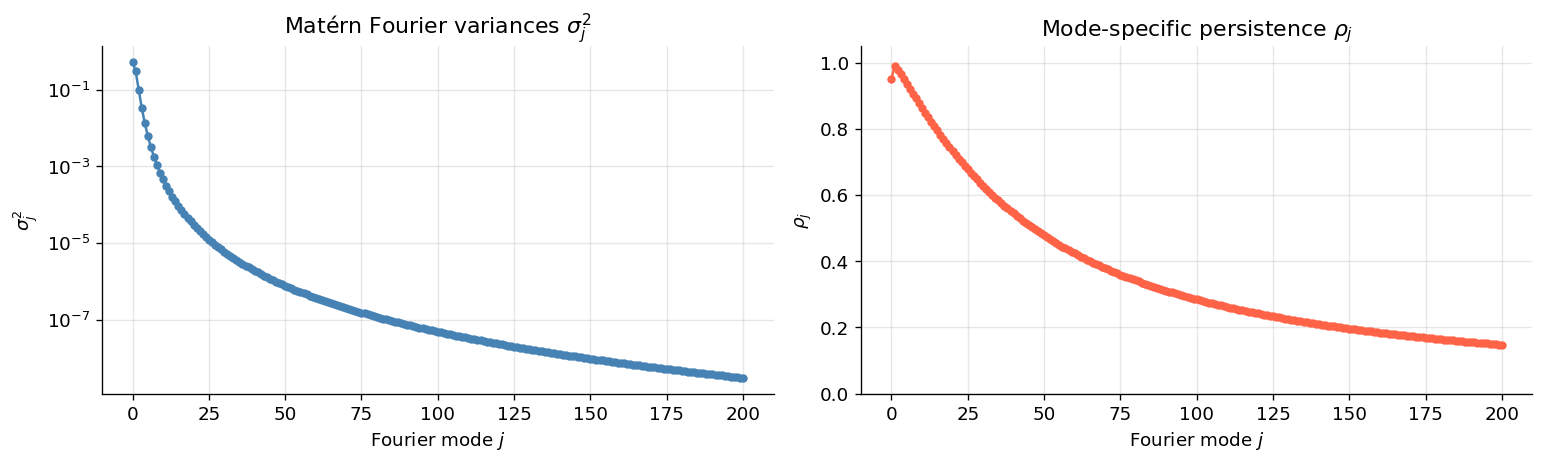

In [26]:
# ── Plot 1: Matérn variances and temporal persistence ──────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

j_all = np.arange(J_sim + 1)
ax1.semilogy(j_all, sim["sigma2"], "o-", ms=4, color="steelblue")
ax1.set(xlabel="Fourier mode $j$", ylabel=r"$\sigma_j^2$", title=r"Matérn Fourier variances $\sigma_j^2$")
ax1.grid(True, alpha=0.3)

ax2.plot(j_all, sim["rho"], "o-", ms=4, color="tomato")
ax2.set(xlabel="Fourier mode $j$", ylabel=r"$\rho_j$",
        title=r"Mode-specific persistence $\rho_j$", ylim=(0, 1.05))
ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


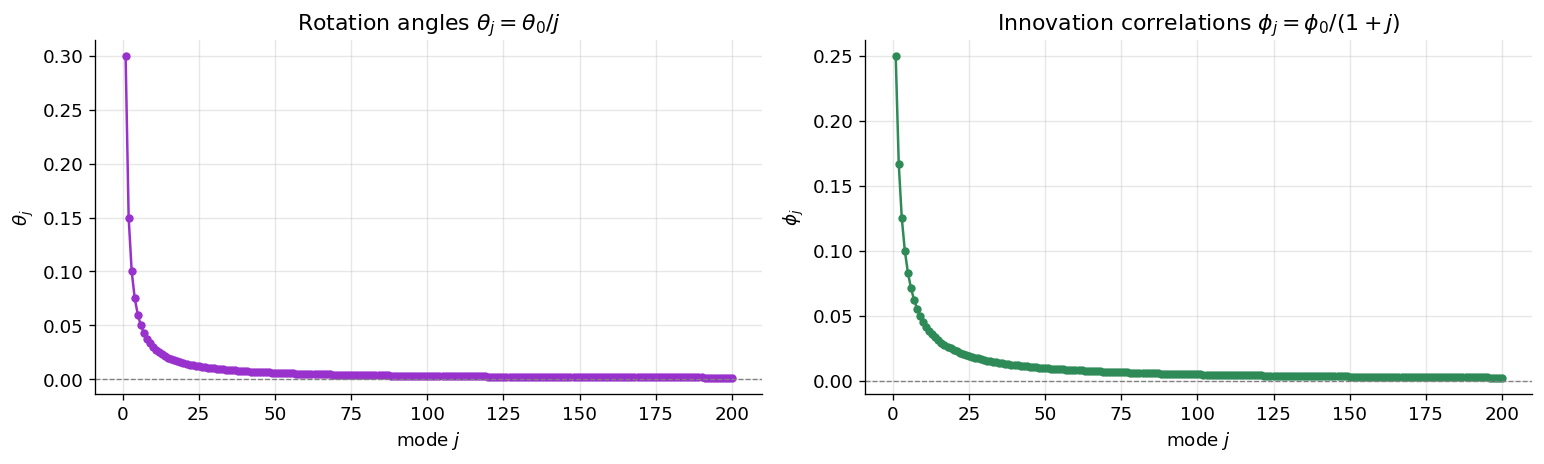

In [27]:
# ── Plot 2: Rotation angles and innovation correlations ───────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
j_mode = np.arange(1, J_sim + 1)

ax1.plot(j_mode, sim["theta_vec"], "o-", ms=4, color="darkorchid")
ax1.axhline(0, color="gray", ls="--", lw=0.8)
ax1.set(xlabel="mode $j$", ylabel=r"$\theta_j$", title=r"Rotation angles $\theta_j = \theta_0/j$")
ax1.grid(True, alpha=0.3)

ax2.plot(j_mode, sim["phi_vec"], "o-", ms=4, color="seagreen")
ax2.axhline(0, color="gray", ls="--", lw=0.8)
ax2.set(xlabel="mode $j$", ylabel=r"$\phi_j$", title=r"Innovation correlations $\phi_j = \phi_0/(1+j)$")
ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


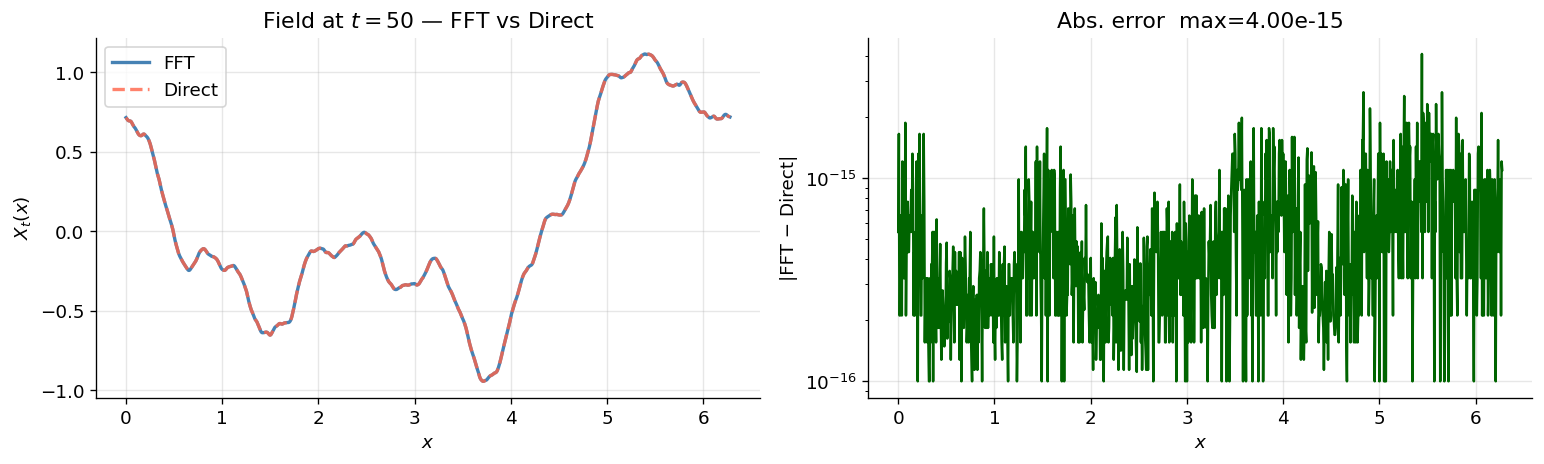

In [28]:
# ── Plot 3: FFT vs Direct accuracy at t=50 ───────────────────────────────────
t_chk = 49
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(x_fft_grid, X_fft[t_chk],     lw=2, label="FFT",    color="steelblue")
ax1.plot(x_fft_grid, X_direct[t_chk],  lw=2, ls="--", label="Direct", color="tomato", alpha=0.8)
ax1.set(xlabel="$x$", ylabel=r"$X_t(x)$", title=f"Field at $t={t_chk+1}$ — FFT vs Direct")
ax1.legend(); ax1.grid(True, alpha=0.3)

err = np.abs(X_fft[t_chk] - X_direct[t_chk])
ax2.semilogy(x_fft_grid, err + 1e-16, lw=1.5, color="darkgreen")
ax2.set(xlabel="$x$", ylabel="|FFT − Direct|", title=f"Abs. error  max={err.max():.2e}")
ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


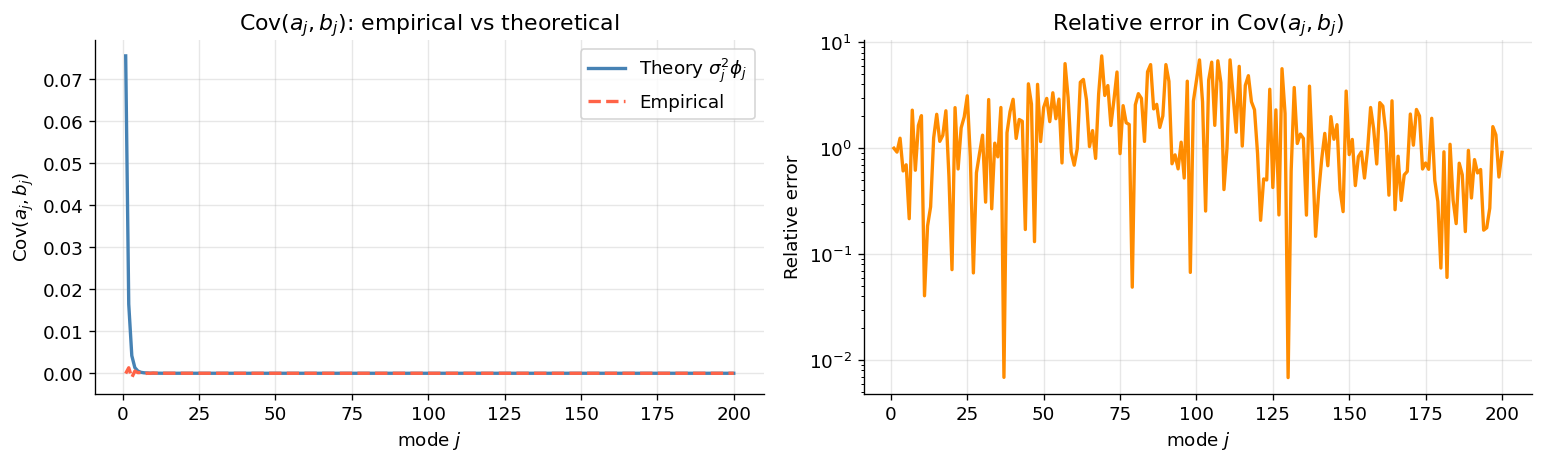

In [29]:
# ── Plot 4: Cov(a_j, b_j) check ──────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(cov_check["j"], cov_check["cov_theory"],    lw=2, label=r"Theory $\sigma_j^2 \phi_j$", color="steelblue")
ax1.plot(cov_check["j"], cov_check["cov_empirical"], lw=2, ls="--", label="Empirical", color="tomato")
ax1.set(xlabel="mode $j$", ylabel=r"$\mathrm{Cov}(a_j,b_j)$",
        title=r"Cov$(a_j, b_j)$: empirical vs theoretical")
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.semilogy(cov_check["j"], cov_check["rel_error"] + 1e-16, lw=2, color="darkorange")
ax2.set(xlabel="mode $j$", ylabel="Relative error",
        title=r"Relative error in Cov$(a_j, b_j)$")
ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


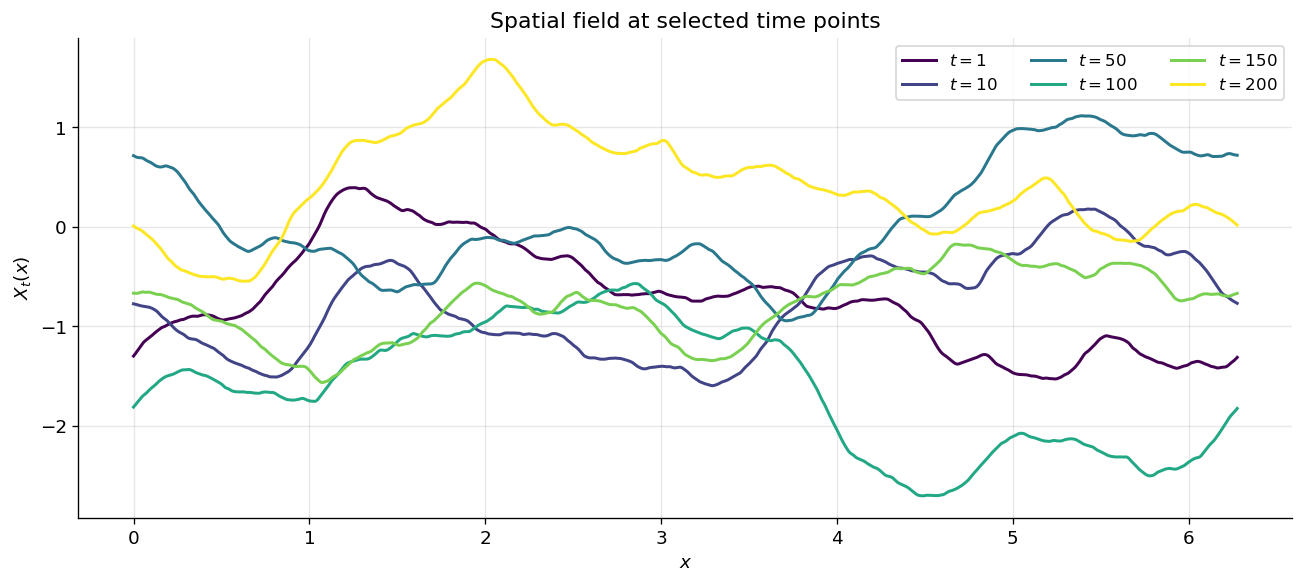

In [30]:
# ── Plot 5: Spatial field at selected times ───────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
t_sel  = [0, 9, 49, 99, 149, 199]
colors = plt.cm.viridis(np.linspace(0, 1, len(t_sel)))
for i, t in enumerate(t_sel):
    ax.plot(x_fft_grid, X_fft[t], lw=1.8, color=colors[i], label=f"$t={t+1}$")
ax.set(xlabel="$x$", ylabel=r"$X_t(x)$", title="Spatial field at selected time points")
ax.legend(ncol=3, fontsize=10); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


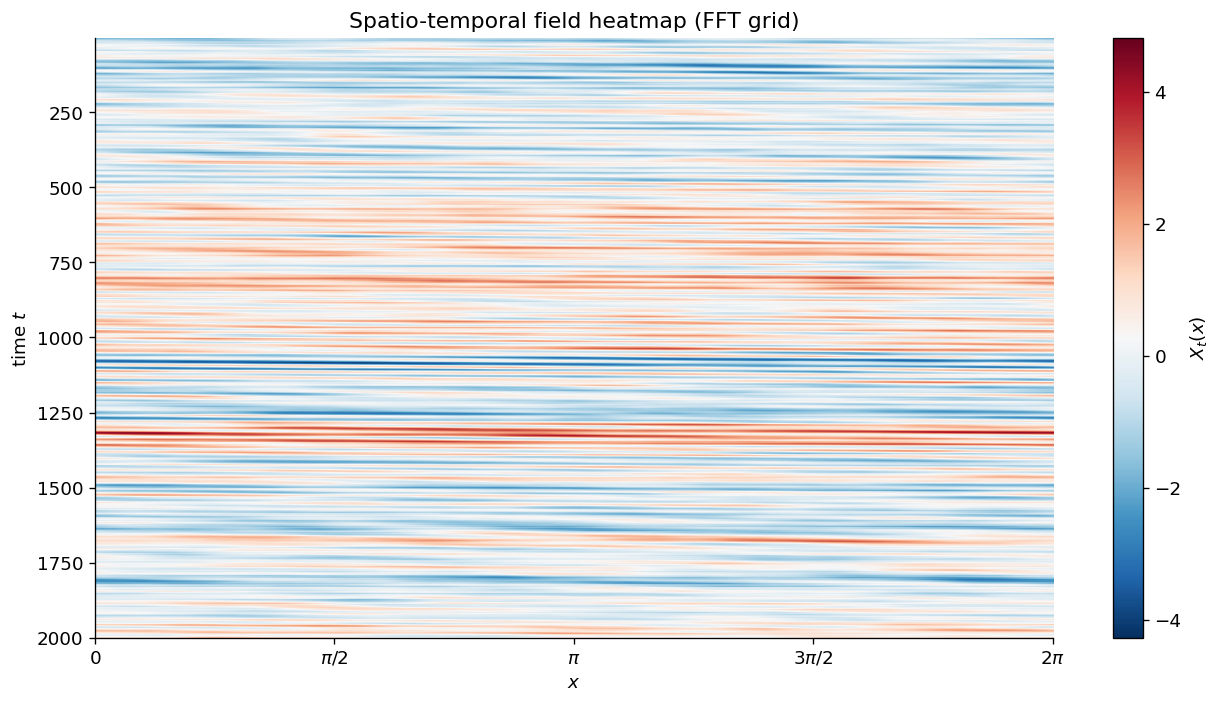

In [31]:
# ── Plot 6: Spatio-temporal heatmap ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))
im = ax.imshow(X_fft, aspect="auto", extent=[0, 2*np.pi, T_sim, 1],
               origin="upper", cmap="RdBu_r")
plt.colorbar(im, ax=ax, label=r"$X_t(x)$")
ax.set(xlabel="$x$", ylabel="time $t$", title="Spatio-temporal field heatmap (FFT grid)")
ax.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
ax.set_xticklabels(["$0$", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
plt.tight_layout(); plt.show()


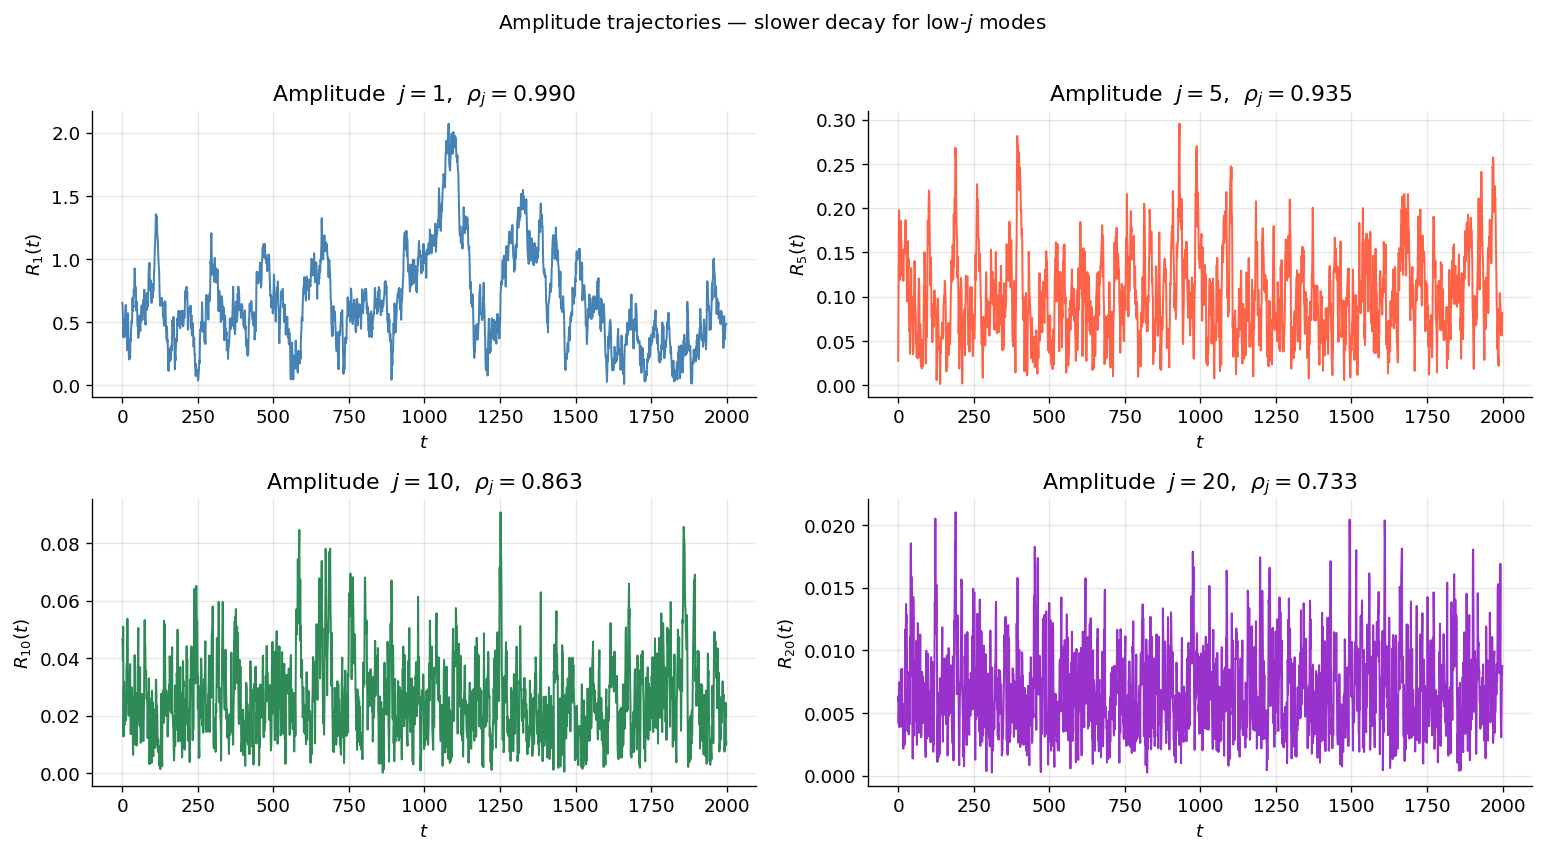

In [32]:
# ── Plot 7: Amplitude trajectories for j = 1, 5, 10, 20 ─────────────────────
modes   = [1, 5, 10, 20]
palette = ["steelblue", "tomato", "seagreen", "darkorchid"]
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
for ax, j, col in zip(axes.ravel(), modes, palette):
    ax.plot(ap["amplitude"][:, j], lw=1.2, color=col)
    ax.set(xlabel="$t$", ylabel=f"$R_{{{j}}}(t)$",
           title=f"Amplitude  $j={j}$,  $\\rho_j={sim['rho'][j]:.3f}$")
    ax.grid(True, alpha=0.3)
plt.suptitle("Amplitude trajectories — slower decay for low-$j$ modes", fontsize=12, y=1.01)
plt.tight_layout(); plt.show()


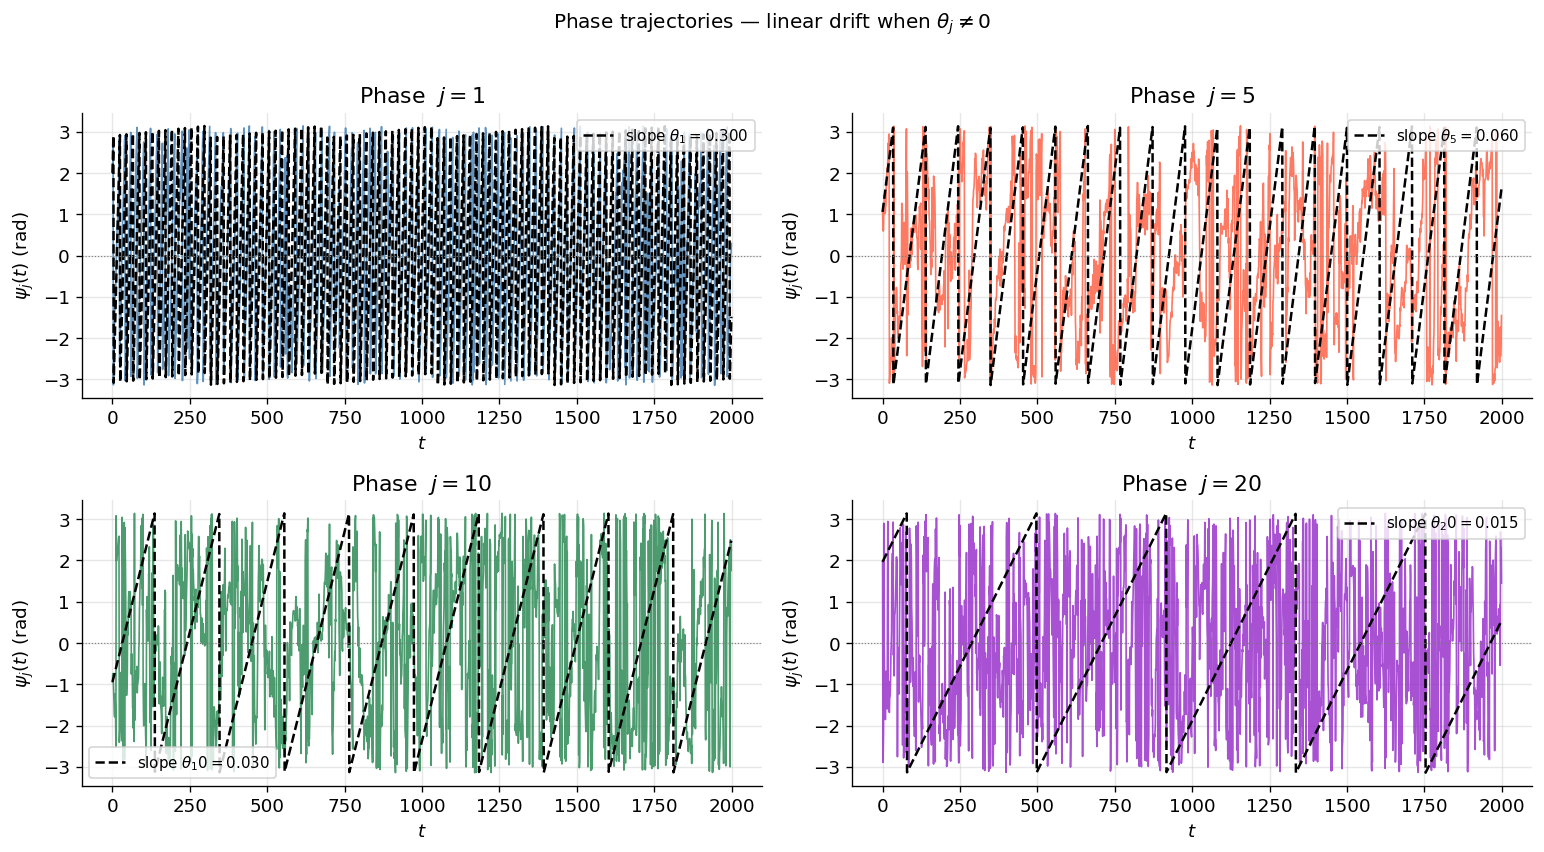

In [33]:
# ── Plot 8: Phase trajectories — rotation drift ───────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
t_arr = np.arange(T_sim)
for ax, j, col in zip(axes.ravel(), modes, palette):
    phs_j = ap["phase"][:, j]
    ax.plot(t_arr, phs_j, lw=1.0, color=col, alpha=0.85)
    # Theoretical drift line (wrapped to [-pi, pi])
    drift = (sim["theta_vec"][j-1] * t_arr + phs_j[0] + np.pi) % (2*np.pi) - np.pi
    ax.plot(t_arr, drift, lw=1.5, ls="--", color="black",
            label=rf"slope $\theta_{j}={sim['theta_vec'][j-1]:.3f}$")
    ax.axhline(0, color="gray", ls=":", lw=0.7)
    ax.set(xlabel="$t$", ylabel=r"$\psi_j(t)$ (rad)",
           title=f"Phase  $j={j}$")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
plt.suptitle(r"Phase trajectories — linear drift when $\theta_j \neq 0$", fontsize=12, y=1.01)
plt.tight_layout(); plt.show()


# ============================================================
# Section 8: Diagnostics
# ============================================================

In [ ]:
def mode_variance_diagnostic(a, b, sigma2):
    J = a.shape[1] - 1
    var_a = np.var(a, axis=0, ddof=1)
    var_b = np.var(b[:, 1:], axis=0, ddof=1)
    out = {
        "j": np.arange(J + 1),
        "var_a": var_a,
        "target_a": sigma2,
        "relerr_a": np.abs(var_a - sigma2) / (sigma2 + 1e-12),
    }
    out["var_b_full"] = np.concatenate([[np.nan], var_b])
    out["relerr_b_full"] = np.concatenate([[np.nan], np.abs(var_b - sigma2[1:]) / (sigma2[1:] + 1e-12)])
    return out

def acf_empirical(x, max_lag=40):
    x = np.asarray(x) - np.mean(x)
    denom = np.dot(x, x)
    vals = [1.0]
    for k in range(1, max_lag + 1):
        vals.append(np.dot(x[:-k], x[k:]) / denom)
    return np.array(vals)

def acf_theory_mode(rho_j, theta_j, phi_j, max_lag=40):
    k = np.arange(max_lag + 1)
    return (rho_j ** k) * (np.cos(k * theta_j) + phi_j * np.sin(k * theta_j))

def phase_slope_diagnostic(a, b, j):
    phase = np.unwrap(np.arctan2(b[:, j], a[:, j]))
    t = np.arange(len(phase))
    slope = np.polyfit(t, phase, 1)[0]
    return {"j": j, "slope_est": slope, "phase": phase}

---
## Summary — R → Python Equivalence Table

| R function | Python function | Notes |
|---|---|---|
| `matern_spectrum()` | `matern_spectrum()` | Identical |
| `rho_function()` | `rho_function()` | `lambda` → `lam` (reserved word) |
| `build_theta_vec()` | `build_theta_vec()` | Identical |
| `build_phi_vec()` | `build_phi_vec()` | Identical |
| `build_Mj()` | `build_Mj()` | Identical |
| `build_Sigma_eps_j()` | `build_Sigma_eps_j()` | Identical |
| `build_Sigma_init_j()` | `build_Sigma_init_j()` | Identical |
| `simulate_fourier_ar1()` | `simulate_fourier_ar1()` | Indexing: R `a[t,j+1]` → Python `a[t,j]` |
| `reconstruct_field()` | `reconstruct_field_direct()` | Renamed for clarity |
| `reconstruct_field_fft()` | `reconstruct_field_fft()` | Same logic, `np.fft.ifft` |
| `amplitude_phase()` | `amplitude_phase()` | Identical |
| `empirical_cov_aj_bj()` | `empirical_cov_check()` | Adds `rel_error` column |
| `validate_fft_accuracy()` | `validate_fft_accuracy()` | Identical purpose |

### Possible Next Steps
- [ ] Whittle likelihood for parameter estimation (`scipy.optimize`)
- [ ] GPU acceleration via `cupy` (drop-in `numpy` replacement)  
- [ ] State-space form connecting to Solin & Särkkä (2014)
- [ ] Periodized Matérn spectrum via Poisson summation
